# Notebook 09 — Lower Model Training

## Objective
Train a classification model specifically for the lower garment region,
using segmented crops extracted in Notebook 08.

## Tasks
| Task | Classes |
|---|---|
| lower_fabric | denim, cotton, leather, furry, knitted, chiffon, other (7 classes) |
| lower_length | three-point, medium short, three-quarter, long (4 classes) |

## Notes
- Input images are cropped to the lower garment region only
- Background replaced with white
- Upper model uses v2 (best_model_v2.pt from Notebook 06)

## Inputs
- `train_lower.csv`, `val_lower.csv`, `test_lower.csv` — splits (Notebook 08)
- `crops/train/lower`, `crops/val/lower`, `crops/test/lower` — cropped images (Notebook 08)

# 1 — Imports & Environment Check

In [9]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
GPU: Tesla T4
PyTorch version: 2.10.0+cu128


# 2 — Configuration

In [10]:
# ── Paths ──────────────────────────────────────────────────────────────────
NB08_DIR = Path("/kaggle/input/notebooks/miguelmirandar/08-segmented-data-preparation")
CROP_DIR = NB08_DIR / "crops"
CKPT_DIR = Path("/kaggle/working/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ── Tasks ─────────────────────────────────────────────────────────────────────
TASKS = {
    "lower_fabric": 7,
    "lower_length": 4,
}

LABEL_MAPS = {
    "lower_fabric": {0:"denim", 1:"cotton", 2:"leather", 3:"furry", 4:"knitted", 5:"chiffon", 6:"other"},
    "lower_length": {0:"three-point", 1:"medium short", 2:"three-quarter", 3:"long"},
}

# ── Hyperparameters ──────────────────────────────────────────────────────────
CFG = {
    "img_size":     224,
    "batch_size":   32,
    "num_workers":  2,
    "epochs":       50,
    "lr":           3e-4,
    "weight_decay": 1e-2,
    "dropout":      0.4,
    "patience":     7,
    "seed":         42,
}

print("Tasks:", TASKS)
print("Config:", CFG)
print(f"Crop dir exists: {CROP_DIR.exists()}")

Tasks: {'lower_fabric': 7, 'lower_length': 4}
Config: {'img_size': 224, 'batch_size': 32, 'num_workers': 2, 'epochs': 50, 'lr': 0.0003, 'weight_decay': 0.01, 'dropout': 0.4, 'patience': 7, 'seed': 42}
Crop dir exists: True


# 3 — Reproducibility, Load Data & Class Weights

In [11]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG["seed"])

# ── Load CSVs ─────────────────────────────────────────────────────────────────
train_df = pd.read_csv(NB08_DIR / "train_lower.csv")
val_df   = pd.read_csv(NB08_DIR / "val_lower.csv")
test_df  = pd.read_csv(NB08_DIR / "test_lower.csv")

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

# ── Compute class weights ─────────────────────────────────────────────────────
def compute_class_weights(df, task, num_classes):
    counts  = df[task].value_counts().sort_index()
    total   = len(df)
    weights = []
    for i in range(num_classes):
        count = counts.get(i, 1)
        weights.append(total / (num_classes * count))
    return torch.tensor(weights, dtype=torch.float32)

class_weights = {
    task: compute_class_weights(train_df, task, num_classes)
    for task, num_classes in TASKS.items()
}

print("\nClass weights:")
for task, w in class_weights.items():
    print(f"  {task}: {[round(x, 3) for x in w.tolist()]}")

print("\nLower fabric distribution (train):")
print(train_df["lower_fabric"].value_counts().sort_index())
print("\nLower length distribution (train):")
print(train_df["lower_length"].value_counts().sort_index())

Train: 8,213 | Val: 1,745 | Test: 1,728

Class weights:
  lower_fabric: [0.362, 0.293, 3.725, 1173.286, 32.591, 1.965, 69.017]
  lower_length: [0.649, 2.892, 6.004, 0.513]

Lower fabric distribution (train):
lower_fabric
0    3237
1    4010
2     315
3       1
4      36
5     597
6      17
Name: count, dtype: int64

Lower length distribution (train):
lower_length
0    3162
1     710
2     342
3    3999
Name: count, dtype: int64


# 3b — Remove Furry class (only 1 training sample)

In [12]:
train_df = train_df[train_df["lower_fabric"] != 3].reset_index(drop=True)
val_df   = val_df[val_df["lower_fabric"]     != 3].reset_index(drop=True)
test_df  = test_df[test_df["lower_fabric"]   != 3].reset_index(drop=True)

# Update tasks
TASKS["lower_fabric"] = 6
LABEL_MAPS["lower_fabric"] = {0:"denim", 1:"cotton", 2:"leather", 3:"knitted", 4:"chiffon", 5:"other"}

# Remap class indices (remove 3, shift 4→3, 5→4, 6→5)
remap = {0:0, 1:1, 2:2, 4:3, 5:4, 6:5}
for df in [train_df, val_df, test_df]:
    df["lower_fabric"] = df["lower_fabric"].map(remap)

# Recompute class weights
class_weights = {
    task: compute_class_weights(train_df, task, num_classes)
    for task, num_classes in TASKS.items()
}

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print("\nClass weights after removing furry:")
for task, w in class_weights.items():
    print(f"  {task}: {[round(x, 3) for x in w.tolist()]}")
print("\nLower fabric distribution (train):")
print(train_df["lower_fabric"].value_counts().sort_index())

Train: 8,212 | Val: 1,744 | Test: 1,728

Class weights after removing furry:
  lower_fabric: [0.423, 0.341, 4.345, 38.019, 2.293, 80.51]
  lower_length: [0.649, 2.892, 6.003, 0.513]

Lower fabric distribution (train):
lower_fabric
0    3237
1    4010
2     315
3      36
4     597
5      17
Name: count, dtype: int64


# 4 — Dataset & DataLoaders

In [13]:
class LowerGarmentDataset(Dataset):
    """Loads cropped lower garment images."""

    def __init__(self, df, crop_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.crop_dir  = Path(crop_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        stem     = Path(row["image_name"]).stem
        img_path = self.crop_dir / f"{stem}.jpg"
        image    = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        labels = {
            "lower_fabric": torch.tensor(row["lower_fabric"], dtype=torch.long),
            "lower_length": torch.tensor(row["lower_length"], dtype=torch.long),
        }
        return image, labels


def get_transforms(split, img_size):
    if split == "train":
        return T.Compose([
            T.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
            T.RandomHorizontalFlip(),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        ])
    else:
        return T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        ])


train_ds = LowerGarmentDataset(train_df, CROP_DIR / "train/lower", get_transforms("train", CFG["img_size"]))
val_ds   = LowerGarmentDataset(val_df,   CROP_DIR / "val/lower",   get_transforms("val",   CFG["img_size"]))

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=CFG["num_workers"], pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)

print(f"Train samples : {len(train_ds):,}")
print(f"Val samples   : {len(val_ds):,}")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

imgs, labels = next(iter(train_loader))
print(f"\nBatch image shape : {imgs.shape}")
print(f"lower_fabric      : {labels['lower_fabric'][:8].tolist()}")
print(f"lower_length      : {labels['lower_length'][:8].tolist()}")

Train samples : 8,212
Val samples   : 1,744
Train batches : 257
Val batches   : 55

Batch image shape : torch.Size([32, 3, 224, 224])
lower_fabric      : [1, 4, 1, 0, 0, 1, 1, 0]
lower_length      : [0, 2, 3, 3, 0, 3, 0, 1]


# 5 — Focal Loss & Model

In [14]:
class FocalLoss(nn.Module):
    """Focal Loss — focuses training on hard, misclassified examples."""

    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets,
                                              weight=self.weight,
                                              reduction="none")
        pt    = torch.exp(-ce_loss)
        focal = (1 - pt) ** self.gamma * ce_loss
        return focal.mean()


class LowerGarmentClassifier(nn.Module):
    """EfficientNet-B0 backbone with 2 parallel classification heads."""

    def __init__(self, tasks, dropout):
        super().__init__()
        backbone      = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.features = backbone.features
        self.avgpool  = backbone.avgpool
        in_features   = backbone.classifier[1].in_features

        self.heads = nn.ModuleDict({
            task: nn.Sequential(
                nn.Dropout(p=dropout),
                nn.Linear(in_features, num_classes),
            )
            for task, num_classes in tasks.items()
        })

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return {task: head(x) for task, head in self.heads.items()}


# ── Instantiate ───────────────────────────────────────────────────────────────
model = LowerGarmentClassifier(TASKS, CFG["dropout"]).to(device)

criteria = {
    task: FocalLoss(weight=class_weights[task].to(device), gamma=2.0)
    for task in TASKS
}

optimizer = AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=CFG["epochs"], eta_min=1e-6)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters : {total_params:,}")
print(f"Dropout          : {CFG['dropout']}")
print(f"Loss             : Focal Loss (gamma=2.0)")

Total parameters : 4,020,358
Dropout          : 0.4
Loss             : Focal Loss (gamma=2.0)


# 6 — Training & Validation Functions with Early Stopping

In [15]:
def train_epoch(model, loader, criteria, optimizer, device):
    model.train()
    total_loss = 0.0
    correct    = {task: 0 for task in TASKS}
    total      = 0

    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs   = imgs.to(device)
        labels = {task: labels[task].to(device) for task in TASKS}

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = sum(criteria[task](outputs[task], labels[task]) for task in TASKS)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        total      += imgs.size(0)
        for task in TASKS:
            preds = outputs[task].argmax(dim=1)
            correct[task] += (preds == labels[task]).sum().item()

    return total_loss / total, {task: correct[task] / total for task in TASKS}


def val_epoch(model, loader, criteria, device):
    model.eval()
    total_loss = 0.0
    correct    = {task: 0 for task in TASKS}
    total      = 0

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Val", leave=False):
            imgs   = imgs.to(device)
            labels = {task: labels[task].to(device) for task in TASKS}

            outputs = model(imgs)
            loss    = sum(criteria[task](outputs[task], labels[task]) for task in TASKS)

            total_loss += loss.item() * imgs.size(0)
            total      += imgs.size(0)
            for task in TASKS:
                preds = outputs[task].argmax(dim=1)
                correct[task] += (preds == labels[task]).sum().item()

    return total_loss / total, {task: correct[task] / total for task in TASKS}


class EarlyStopping:
    def __init__(self, patience, ckpt_path):
        self.patience  = patience
        self.ckpt_path = ckpt_path
        self.best_loss = float("inf")
        self.counter   = 0

    def step(self, val_loss, epoch, model, optimizer):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save({
                "epoch":                epoch,
                "model_state_dict":     model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss":             val_loss,
            }, self.ckpt_path)
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience


print("Functions and EarlyStopping defined.")

Functions and EarlyStopping defined.


# 7 — Training Loop

In [16]:
history    = []
early_stop = EarlyStopping(patience=CFG["patience"], ckpt_path=CKPT_DIR / "best_lower_model.pt")

for epoch in range(1, CFG["epochs"] + 1):

    train_loss, train_acc = train_epoch(model, train_loader, criteria, optimizer, device)
    val_loss,   val_acc   = val_epoch(model,   val_loader,   criteria,            device)
    scheduler.step()

    history.append({
        "epoch":            epoch,
        "train_loss":       train_loss,
        "val_loss":         val_loss,
        "train_acc_fabric": train_acc["lower_fabric"],
        "train_acc_length": train_acc["lower_length"],
        "val_acc_fabric":   val_acc["lower_fabric"],
        "val_acc_length":   val_acc["lower_length"],
    })

    print(
        f"Epoch {epoch:02d}/{CFG['epochs']} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc — fabric: {val_acc['lower_fabric']:.3f} "
        f"length: {val_acc['lower_length']:.3f}"
    )

    stop = early_stop.step(val_loss, epoch, model, optimizer)
    if stop:
        print(f"\n  Early stopping triggered at epoch {epoch} (patience={CFG['patience']})")
        break
    elif val_loss == early_stop.best_loss:
        print(f"  Best model saved (val_loss={val_loss:.4f})")

print("\nTraining complete.")

Train:   0%|          | 0/257 [00:00<?, ?it/s]

Val:   0%|          | 0/55 [00:00<?, ?it/s]

Epoch 01/50 | Train loss: 1.5278 | Val loss: 1.2578 | Val acc — fabric: 0.453 length: 0.636
  Best model saved (val_loss=1.2578)


Train:   0%|          | 0/257 [00:00<?, ?it/s]

Val:   0%|          | 0/55 [00:00<?, ?it/s]

...

Val:   0%|          | 0/55 [00:00<?, ?it/s]

Epoch 07/50 | Train loss: 0.3623 | Val loss: 1.3023 | Val acc — fabric: 0.662 length: 0.712


Train:   0%|          | 0/257 [00:00<?, ?it/s]

Val:   0%|          | 0/55 [00:00<?, ?it/s]

Epoch 08/50 | Train loss: 0.4118 | Val loss: 1.5477 | Val acc — fabric: 0.651 length: 0.625

  Early stopping triggered at epoch 8 (patience=7)

Training complete.


# 8 — Evaluation on Test Set

In [17]:
from sklearn.metrics import classification_report

checkpoint = torch.load(CKPT_DIR / "best_lower_model.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Best model from epoch : {checkpoint['epoch']}")
print(f"Val loss              : {checkpoint['val_loss']:.4f}")

test_ds     = LowerGarmentDataset(test_df, CROP_DIR / "test/lower", get_transforms("val", CFG["img_size"]))
test_loader = DataLoader(test_ds, batch_size=CFG["batch_size"], shuffle=False,
                         num_workers=CFG["num_workers"], pin_memory=True)

all_preds  = {task: [] for task in TASKS}
all_labels = {task: [] for task in TASKS}

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs    = imgs.to(device)
        outputs = model(imgs)
        for task in TASKS:
            all_preds[task].extend(outputs[task].argmax(dim=1).cpu().numpy())
            all_labels[task].extend(labels[task].numpy())

all_preds  = {task: np.array(all_preds[task])  for task in TASKS}
all_labels = {task: np.array(all_labels[task]) for task in TASKS}

print("\nTest Accuracy:")
for task in TASKS:
    acc = (all_preds[task] == all_labels[task]).mean()
    print(f"  {task}: {acc:.4f}")

for task in TASKS:
    label_names = [LABEL_MAPS[task][i] for i in range(TASKS[task])]
    print(f"\n{'='*60}")
    print(f" Task: {task}")
    print(f"{'='*60}")
    print(classification_report(all_labels[task], all_preds[task],
                                 target_names=label_names, zero_division=0))

Best model from epoch : 1
Val loss              : 1.2578


Evaluating:   0%|          | 0/54 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x790ece3358a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x790ece3358a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


Test Accuracy:
  lower_fabric: 0.4641
  lower_length: 0.6238

 Task: lower_fabric
              precision    recall  f1-score   support

       denim       0.80      0.79      0.80       672
      cotton       0.88      0.13      0.22       832
     leather       0.23      0.92      0.36        78
     knitted       0.03      0.80      0.05         5
     chiffon       0.34      0.63      0.44       136
       other       0.00      0.20      0.01         5

    accuracy                           0.46      1728
   macro avg       0.38      0.58      0.31      1728
weighted avg       0.77      0.46      0.47      1728


 Task: lower_length
               precision    recall  f1-score   support

  three-point       0.82      0.71      0.76       650
 medium short       0.24      0.69      0.36       133
three-quarter       0.07      0.25      0.11        75
         long       0.98      0.58      0.73       870

     accuracy                           0.62      1728
    macro avg       0

# 9 — Training Curves & Summary

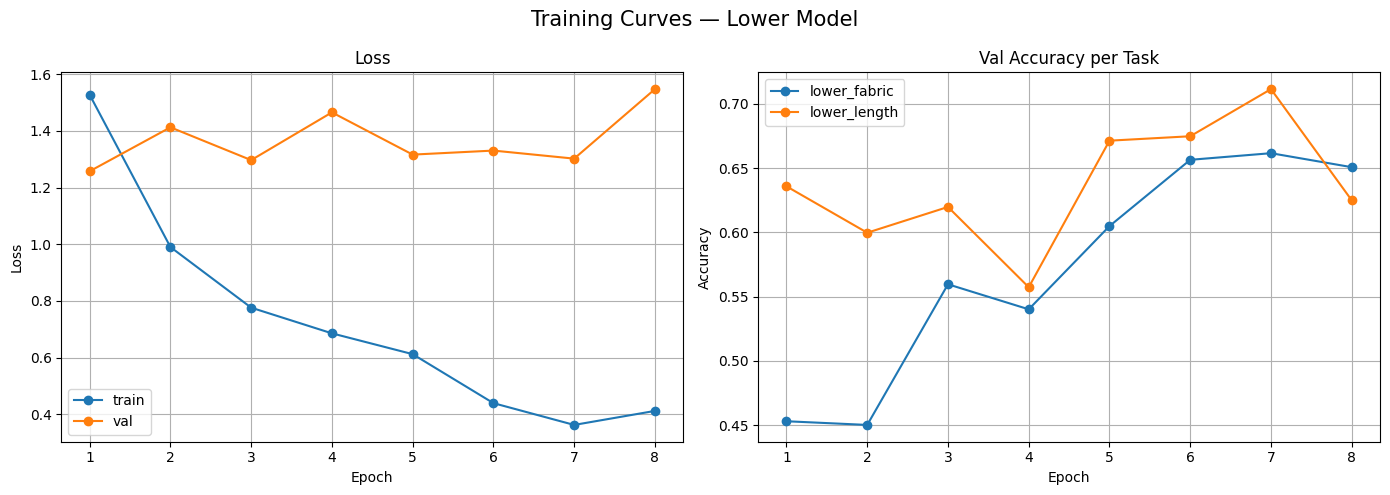

Saved: training_curves_lower.png, training_history_lower.csv

Final Test Results — Lower Model:
  lower_fabric : 0.4641
  lower_length : 0.6238


In [18]:
df_hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_hist["epoch"], df_hist["train_loss"], label="train", marker="o")
axes[0].plot(df_hist["epoch"], df_hist["val_loss"],   label="val",   marker="o")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df_hist["epoch"], df_hist["val_acc_fabric"], label="lower_fabric", marker="o")
axes[1].plot(df_hist["epoch"], df_hist["val_acc_length"], label="lower_length", marker="o")
axes[1].set_title("Val Accuracy per Task")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Training Curves — Lower Model", fontsize=15)
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_lower.png", dpi=150)
plt.show()

df_hist.to_csv("/kaggle/working/training_history_lower.csv", index=False)
print("Saved: training_curves_lower.png, training_history_lower.csv")

print("\nFinal Test Results — Lower Model:")
print(f"  lower_fabric : 0.4641")
print(f"  lower_length : 0.6238")